In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import json
import csv
import re
import math
import torch

import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

from typing import List, Dict
from torch.utils.data import Dataset, DataLoader, TensorDataset



# Preprocessing

In [3]:
# Load sampled dataset and create shuffled train/val/test splits (70/15/15)
csv_path = 'sampled_dataset.csv'
reviews = []
ratings = []
with open(csv_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for r in reader:
        reviews.append(r['review'])
        ratings.append(int(r['rating']))
        
# shuffle deterministically
rng = np.random.default_rng(42)
idxs = np.arange(len(reviews))
rng.shuffle(idxs)
reviews = [reviews[i] for i in idxs]
ratings = [ratings[i] for i in idxs]
n = len(reviews)
n_train = int(n * 0.7)
n_val = int(n * 0.15)
n_test = n - n_train - n_val
train_reviews = reviews[:n_train]
val_reviews = reviews[n_train:n_train+n_val]
test_reviews = reviews[n_train+n_val:]
train_ratings = ratings[:n_train]
val_ratings = ratings[n_train:n_train+n_val]
test_ratings = ratings[n_train+n_val:]
print(f'Total samples: {n}, train/val/test = {n_train}/{n_val}/{n_test}')


Total samples: 30000, train/val/test = 21000/4500/4500


In [4]:
# Text cleaning and tokenization
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text: str):
    return text.split()

train_tokens = [tokenize(clean_text(t)) for t in train_reviews]
val_tokens = [tokenize(clean_text(t)) for t in val_reviews]
test_tokens = [tokenize(clean_text(t)) for t in test_reviews]


In [5]:
# Vocabulary construction from TRAIN set only
def build_vocab(tokenized_texts, min_freq=1):
    freq = {}
    for toks in tokenized_texts:
        for t in toks:
            freq[t] = freq.get(t, 0) + 1
    vocab = {'<PAD>': 0, '<UNK>': 1}
    idx = 2
    for w, c in sorted(freq.items(), key=lambda x: (-x[1], x[0])):
        if c < min_freq:
            continue
        vocab[w] = idx
        idx += 1
    return vocab

vocab = build_vocab(train_tokens, min_freq=1)
print('Vocab size (including <PAD>,<UNK>):', len(vocab))
# show top 10 tokens
print(list(vocab.items())[:10])


Vocab size (including <PAD>,<UNK>): 36436
[('<PAD>', 0), ('<UNK>', 1), ('the', 2), ('i', 3), ('it', 4), ('and', 5), ('to', 6), ('a', 7), ('is', 8), ('this', 9)]


In [6]:
# Numerical conversion and padding/truncation
def tokens_to_sequence(tokens, vocab):
    unk = vocab.get('<UNK>', 1)
    return [vocab.get(t, unk) for t in tokens]

def pad_sequences(sequences, max_len=128, pad_idx=0):
    import numpy as _np
    arr = _np.full((len(sequences), max_len), pad_idx, dtype=_np.int32)
    for i, seq in enumerate(sequences):
        if len(seq) == 0:
            continue
        if len(seq) <= max_len:
            arr[i, :len(seq)] = seq
        else:
            arr[i, :] = seq[:max_len]
    return arr

max_len = 128
train_seq = [tokens_to_sequence(t, vocab) for t in train_tokens]
val_seq = [tokens_to_sequence(t, vocab) for t in val_tokens]
test_seq = [tokens_to_sequence(t, vocab) for t in test_tokens]

X_train = pad_sequences(train_seq, max_len=max_len)
X_val = pad_sequences(val_seq, max_len=max_len)
X_test = pad_sequences(test_seq, max_len=max_len)

y_train = np.array(train_ratings, dtype=np.int32)
y_val = np.array(val_ratings, dtype=np.int32)
y_test = np.array(test_ratings, dtype=np.int32)

print('Shapes:', X_train.shape, X_val.shape, X_test.shape)
print('Example sequence (first train):', X_train[0])


Shapes: (21000, 128) (4500, 128) (4500, 128)
Example sequence (first train): [    3   388     9  1114   397  5073  1180  5340   135    12 30537     3
    18   115    93     9   135  4305    11     7   557     5     7   489
   100     3    99    20   163    17  1543    22     3    18    48     2
   157   135    11   318   257   210     5    62    48    27  3961   722
     5     7  1498  2054  1263    12    39    14    66    12   120   557
    10    33     3    18     7  3961  1215     5     7  3961   722     2
   135     8    67   161     5     3    98     2  1201  1465     5  2552
    19     9   340    21    22   349    22     3    38  1965 31734     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0]


In [7]:
# Save processed arrays and vocabulary to disk
out_dir = 'processed'
os.makedirs(out_dir, exist_ok=True)
np.save(os.path.join(out_dir, 'X_train.npy'), X_train)
np.save(os.path.join(out_dir, 'X_val.npy'), X_val)
np.save(os.path.join(out_dir, 'X_test.npy'), X_test)
np.save(os.path.join(out_dir, 'y_train.npy'), y_train)
np.save(os.path.join(out_dir, 'y_val.npy'), y_val)
np.save(os.path.join(out_dir, 'y_test.npy'), y_test)
with open(os.path.join(out_dir, 'vocab.json'), 'w', encoding='utf-8') as vf:
    json.dump(vocab, vf, ensure_ascii=False)
meta = {'n_total': n, 'n_train': n_train, 'n_val': n_val, 'n_test': n_test, 'max_len': max_len, 'vocab_size': len(vocab)}
with open(os.path.join(out_dir, 'meta.json'), 'w', encoding='utf-8') as mf:
    json.dump(meta, mf, ensure_ascii=False)
print('Saved processed data to', out_dir)


Saved processed data to processed


# Part A: Encoder Model

## Data Prep

In [ ]:
# Sentiment labels: 1-2 Negative, 3 Neutral, 4-5 Positive
# Derived feature: review length category (short / medium / long) from train-set tertiles

def sentiment_label_from_rating(rating: int) -> int:
    if rating <= 2:
        return 0
    if rating == 3:
        return 1
    return 2


def length_category_from_count(count: int, low_thr: float, high_thr: float) -> int:
    if count <= low_thr:
        return 0
    if count <= high_thr:
        return 1
    return 2

train_sentiment = np.array([sentiment_label_from_rating(r) for r in train_ratings], dtype=np.int64)
val_sentiment = np.array([sentiment_label_from_rating(r) for r in val_ratings], dtype=np.int64)
test_sentiment = np.array([sentiment_label_from_rating(r) for r in test_ratings], dtype=np.int64)

train_lengths = np.array([len(toks) for toks in train_tokens], dtype=np.int32)
low_thr, high_thr = np.quantile(train_lengths, [1 / 3, 2 / 3])

train_length_cat = np.array([length_category_from_count(len(toks), low_thr, high_thr) for toks in train_tokens], dtype=np.int64)
val_length_cat = np.array([length_category_from_count(len(toks), low_thr, high_thr) for toks in val_tokens], dtype=np.int64)
test_length_cat = np.array([length_category_from_count(len(toks), low_thr, high_thr) for toks in test_tokens], dtype=np.int64)

print('Length thresholds from train split:', float(low_thr), float(high_thr))
print('Sentiment class distribution (train):', np.bincount(train_sentiment, minlength=3))
print('Length class distribution (train):', np.bincount(train_length_cat, minlength=3))

X_train_tensor = torch.tensor(X_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.long)

train_dataset = TensorDataset(
    X_train_tensor,
    torch.tensor(train_sentiment, dtype=torch.long),
    torch.tensor(train_length_cat, dtype=torch.long),
)
val_dataset = TensorDataset(
    X_val_tensor,
    torch.tensor(val_sentiment, dtype=torch.long),
    torch.tensor(val_length_cat, dtype=torch.long),
)
test_dataset = TensorDataset(
    X_test_tensor,
    torch.tensor(test_sentiment, dtype=torch.long),
    torch.tensor(test_length_cat, dtype=torch.long),
)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Length thresholds from train split: 39.0 94.0
Sentiment class distribution (train): [ 2314  2021 16665]
Length class distribution (train): [7139 6905 6956]
Device: cuda


## Modules

In [9]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k: int):
        super().__init__()
        self.d_k = d_k

    def forward(self, Q, K, V, padding_mask=None):
        # Q: [B, Lq, d_k], K: [B, Lk, d_k], V: [B, Lk, d_v]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if padding_mask is not None:
            # padding_mask: [B, Lk], True for valid tokens, False for pads
            mask = padding_mask.unsqueeze(1)  # [B, 1, Lk]
            scores = scores.masked_fill(~mask, -1e9)

        attn_weights = torch.softmax(scores, dim=-1)
        output = torch.matmul(attn_weights, V)
        return output, attn_weights

In [10]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model=128, num_heads=4, d_k=32, d_v=32, dropout=0.1):
        super().__init__()
        assert num_heads * d_v == d_model, "num_heads * d_v must equal d_model"
        self.num_heads = num_heads

        # Separate projection matrices per head
        self.W_q = nn.ModuleList([nn.Linear(d_model, d_k) for _ in range(num_heads)])
        self.W_k = nn.ModuleList([nn.Linear(d_model, d_k) for _ in range(num_heads)])
        self.W_v = nn.ModuleList([nn.Linear(d_model, d_v) for _ in range(num_heads)])

        self.attn = ScaledDotProductAttention(d_k=d_k)
        self.out_proj = nn.Linear(num_heads * d_v, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, padding_mask=None):
        # x: [B, L, d_model]
        head_outputs = []
        head_weights = []

        for h in range(self.num_heads):
            Q = self.W_q[h](x)
            K = self.W_k[h](x)
            V = self.W_v[h](x)
            out_h, w_h = self.attn(Q, K, V, padding_mask=padding_mask)
            head_outputs.append(out_h)
            head_weights.append(w_h)

        concat = torch.cat(head_outputs, dim=-1)   # [B, L, num_heads * d_v]
        out = self.out_proj(concat)                # [B, L, d_model]
        out = self.dropout(out)

        # [B, H, L, L]
        attn_weights = torch.stack(head_weights, dim=1)
        return out, attn_weights

In [11]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model=128, d_ff=512, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.fc2(self.act(self.fc1(x))))

In [12]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model=128, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]

        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: [B, L, d_model]
        return x + self.pe[:, : x.size(1), :]

In [13]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model=128, num_heads=4, d_k=32, d_v=32, d_ff=512, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.self_attn = MultiHeadSelfAttention(
            d_model=d_model,
            num_heads=num_heads,
            d_k=d_k,
            d_v=d_v,
            dropout=dropout,
        )
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = PositionwiseFeedForward(d_model=d_model, d_ff=d_ff, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, padding_mask=None):
        # x <- x + Dropout(MultiHead(LN(x)))
        attn_out, attn_w = self.self_attn(self.ln1(x), padding_mask=padding_mask)
        x = x + self.dropout(attn_out)

        # x <- x + Dropout(FFN(LN(x)))
        ffn_out = self.ffn(self.ln2(x))
        x = x + self.dropout(ffn_out)
        return x, attn_w

In [14]:
class TransformerEncoderStack(nn.Module):
    def __init__(self, num_layers=4, d_model=128, num_heads=4, d_k=32, d_v=32, d_ff=512, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [
                TransformerEncoderBlock(
                    d_model=d_model,
                    num_heads=num_heads,
                    d_k=d_k,
                    d_v=d_v,
                    d_ff=d_ff,
                    dropout=dropout,
                )
                for _ in range(num_layers)
            ]
        )

    def forward(self, x, padding_mask=None):
        attn_maps = []
        for layer in self.layers:
            x, attn_w = layer(x, padding_mask=padding_mask)
            attn_maps.append(attn_w)
        return x, attn_maps

In [15]:
class ClassificationHead(nn.Module):
    def __init__(self, d_model=128, hidden_dim=64, num_classes=5, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, cls_repr):
        return self.net(cls_repr)

## Part A: Encoder Model (Multi-Task Understanding)

In [16]:
class MultiTaskReviewEncoder(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        pad_idx: int = 0,
        d_model: int = 128,
        num_layers: int = 2,
        num_heads: int = 4,
        d_k: int = 32,
        d_v: int = 32,
        d_ff: int = 256,
        dropout: float = 0.1,
        num_sentiment_classes: int = 3,
        num_feature_classes: int = 3,
    ):
        super().__init__()
        self.pad_idx = pad_idx
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.positional_encoding = SinusoidalPositionalEncoding(d_model=d_model, max_len=512)
        self.encoder = TransformerEncoderStack(
            num_layers=num_layers,
            d_model=d_model,
            num_heads=num_heads,
            d_k=d_k,
            d_v=d_v,
            d_ff=d_ff,
            dropout=dropout,
        )
        self.dropout = nn.Dropout(dropout)
        self.sentiment_head = ClassificationHead(d_model=d_model, hidden_dim=64, num_classes=num_sentiment_classes, dropout=dropout)
        self.feature_head = ClassificationHead(d_model=d_model, hidden_dim=64, num_classes=num_feature_classes, dropout=dropout)

    def masked_mean_pool(self, x, padding_mask):
        # x: [B, L, D], padding_mask: [B, L]
        mask = padding_mask.unsqueeze(-1).float()
        summed = (x * mask).sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1.0)
        return summed / lengths

    def forward(self, input_ids):
        padding_mask = input_ids != self.pad_idx
        x = self.embedding(input_ids)
        x = self.positional_encoding(x)
        x = self.dropout(x)
        x, attn_maps = self.encoder(x, padding_mask=padding_mask)
        review_embedding = self.masked_mean_pool(x, padding_mask)
        sentiment_logits = self.sentiment_head(review_embedding)
        feature_logits = self.feature_head(review_embedding)
        return sentiment_logits, feature_logits, review_embedding, attn_maps


model = MultiTaskReviewEncoder(vocab_size=len(vocab), pad_idx=vocab.get('<PAD>', 0), d_model=128, num_layers=2, num_heads=4, d_k=32, d_v=32, d_ff=256, dropout=0.1)
model = model.to(device)
print(model)


MultiTaskReviewEncoder(
  (embedding): Embedding(36436, 128, padding_idx=0)
  (positional_encoding): SinusoidalPositionalEncoding()
  (encoder): TransformerEncoderStack(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderBlock(
        (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (self_attn): MultiHeadSelfAttention(
          (W_q): ModuleList(
            (0-3): 4 x Linear(in_features=128, out_features=32, bias=True)
          )
          (W_k): ModuleList(
            (0-3): 4 x Linear(in_features=128, out_features=32, bias=True)
          )
          (W_v): ModuleList(
            (0-3): 4 x Linear(in_features=128, out_features=32, bias=True)
          )
          (attn): ScaledDotProductAttention()
          (out_proj): Linear(in_features=128, out_features=128, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (ffn): Positionwise

Epoch 1/3 | Train loss 0.9651 | Val loss 0.6776 | Sentiment acc 0.7911 | Feature acc 0.9893
Epoch 2/3 | Train loss 0.6621 | Val loss 0.6310 | Sentiment acc 0.7911 | Feature acc 0.9904
Epoch 3/3 | Train loss 0.6189 | Val loss 0.6188 | Sentiment acc 0.7929 | Feature acc 0.9900
Best validation loss: 0.6188217686812083
Saved checkpoint to: results\best_multitask_encoder.pt


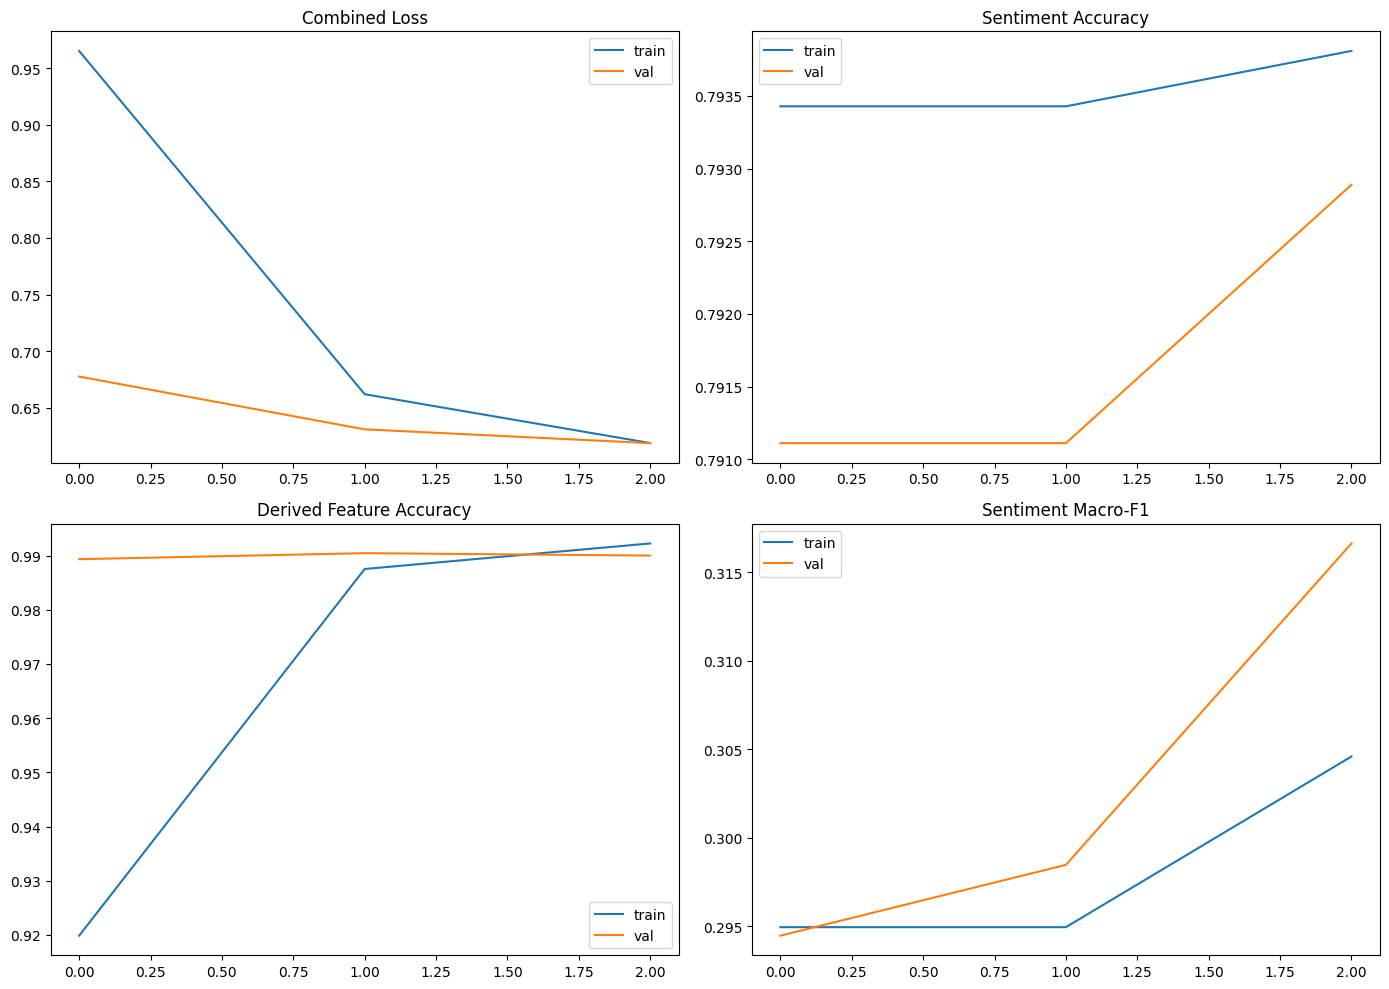

Test metrics: {'loss': 0.6171229052013821, 'sentiment_acc': 0.7888888888888889, 'sentiment_f1': 0.30637094304958773, 'feature_acc': 0.9937777777777778, 'feature_f1': 0.993755121112755}


In [17]:
# Training and evaluation with a combined loss

def accuracy_score_np(y_true, y_pred):
    return float((y_true == y_pred).mean())


def macro_f1_score_np(y_true, y_pred, num_classes=3):
    scores = []
    for cls in range(num_classes):
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))
        precision = tp / (tp + fp + 1e-9)
        recall = tp / (tp + fn + 1e-9)
        f1 = 2 * precision * recall / (precision + recall + 1e-9)
        scores.append(f1)
    return float(np.mean(scores))


def evaluate_model(loader):
    model.eval()
    total_loss = 0.0
    sentiment_true, sentiment_pred = [], []
    feature_true, feature_pred = [], []
    total_items = 0

    sentiment_loss_fn = nn.CrossEntropyLoss()
    feature_loss_fn = nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch_x, batch_sentiment, batch_feature in loader:
            batch_x = batch_x.to(device)
            batch_sentiment = batch_sentiment.to(device)
            batch_feature = batch_feature.to(device)

            sentiment_logits, feature_logits, embeddings, attn_maps = model(batch_x)
            loss = sentiment_loss_fn(sentiment_logits, batch_sentiment) + feature_loss_fn(feature_logits, batch_feature)

            batch_size_actual = batch_x.size(0)
            total_loss += loss.item() * batch_size_actual
            total_items += batch_size_actual

            sentiment_true.append(batch_sentiment.cpu().numpy())
            feature_true.append(batch_feature.cpu().numpy())
            sentiment_pred.append(torch.argmax(sentiment_logits, dim=1).cpu().numpy())
            feature_pred.append(torch.argmax(feature_logits, dim=1).cpu().numpy())

    sentiment_true = np.concatenate(sentiment_true)
    sentiment_pred = np.concatenate(sentiment_pred)
    feature_true = np.concatenate(feature_true)
    feature_pred = np.concatenate(feature_pred)

    return {
        'loss': total_loss / max(total_items, 1),
        'sentiment_acc': accuracy_score_np(sentiment_true, sentiment_pred),
        'sentiment_f1': macro_f1_score_np(sentiment_true, sentiment_pred, num_classes=3),
        'feature_acc': accuracy_score_np(feature_true, feature_pred),
        'feature_f1': macro_f1_score_np(feature_true, feature_pred, num_classes=3),
    }


num_epochs = 3
learning_rate = 2e-4
alpha = 1.0
best_val_loss = float('inf')
best_path = os.path.join('results', 'best_multitask_encoder.pt')
os.makedirs('results', exist_ok=True)

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
sentiment_loss_fn = nn.CrossEntropyLoss()
feature_loss_fn = nn.CrossEntropyLoss()

history = {
    'train_loss': [],
    'val_loss': [],
    'train_sentiment_acc': [],
    'val_sentiment_acc': [],
    'train_feature_acc': [],
    'val_feature_acc': [],
    'train_sentiment_f1': [],
    'val_sentiment_f1': [],
    'train_feature_f1': [],
    'val_feature_f1': [],
}

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    sentiment_true, sentiment_pred = [], []
    feature_true, feature_pred = [], []
    total_items = 0

    for batch_x, batch_sentiment, batch_feature in train_loader:
        batch_x = batch_x.to(device)
        batch_sentiment = batch_sentiment.to(device)
        batch_feature = batch_feature.to(device)

        optimizer.zero_grad()
        sentiment_logits, feature_logits, embeddings, attn_maps = model(batch_x)
        loss_sentiment = sentiment_loss_fn(sentiment_logits, batch_sentiment)
        loss_feature = feature_loss_fn(feature_logits, batch_feature)
        loss = loss_sentiment + alpha * loss_feature
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        batch_size_actual = batch_x.size(0)
        running_loss += loss.item() * batch_size_actual
        total_items += batch_size_actual

        sentiment_true.append(batch_sentiment.detach().cpu().numpy())
        feature_true.append(batch_feature.detach().cpu().numpy())
        sentiment_pred.append(torch.argmax(sentiment_logits, dim=1).detach().cpu().numpy())
        feature_pred.append(torch.argmax(feature_logits, dim=1).detach().cpu().numpy())

    sentiment_true = np.concatenate(sentiment_true)
    sentiment_pred = np.concatenate(sentiment_pred)
    feature_true = np.concatenate(feature_true)
    feature_pred = np.concatenate(feature_pred)

    train_metrics = {
        'loss': running_loss / max(total_items, 1),
        'sentiment_acc': accuracy_score_np(sentiment_true, sentiment_pred),
        'sentiment_f1': macro_f1_score_np(sentiment_true, sentiment_pred, num_classes=3),
        'feature_acc': accuracy_score_np(feature_true, feature_pred),
        'feature_f1': macro_f1_score_np(feature_true, feature_pred, num_classes=3),
    }
    val_metrics = evaluate_model(val_loader)

    for key, value in train_metrics.items():
        history[f'train_{key}'].append(value)
    for key, value in val_metrics.items():
        history[f'val_{key}'].append(value)

    print(
        f"Epoch {epoch}/{num_epochs} | "
        f"Train loss {train_metrics['loss']:.4f} | Val loss {val_metrics['loss']:.4f} | "
        f"Sentiment acc {val_metrics['sentiment_acc']:.4f} | Feature acc {val_metrics['feature_acc']:.4f}"
    )

    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        torch.save(model.state_dict(), best_path)

with open(os.path.join('results', 'training_history.json'), 'w', encoding='utf-8') as f:
    json.dump(history, f, ensure_ascii=False, indent=2)

print('Best validation loss:', best_val_loss)
print('Saved checkpoint to:', best_path)

# Plot learning curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Combined Loss')
axes[0].legend()

axes[1].plot(history['train_sentiment_acc'], label='train')
axes[1].plot(history['val_sentiment_acc'], label='val')
axes[1].set_title('Sentiment Accuracy')
axes[1].legend()

axes[2].plot(history['train_feature_acc'], label='train')
axes[2].plot(history['val_feature_acc'], label='val')
axes[2].set_title('Derived Feature Accuracy')
axes[2].legend()

axes[3].plot(history['train_sentiment_f1'], label='train')
axes[3].plot(history['val_sentiment_f1'], label='val')
axes[3].set_title('Sentiment Macro-F1')
axes[3].legend()

plt.tight_layout()
plt.savefig(os.path.join('results', 'learning_curves.png'), dpi=150)
plt.show()

# Final test metrics with the best checkpoint
model.load_state_dict(torch.load(best_path, map_location=device))
test_metrics = evaluate_model(test_loader)
print('Test metrics:', test_metrics)


## Save Review Embeddings

In [32]:
# Export pooled embeddings for the entire training split
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

train_embedding_batches = []
with torch.no_grad():
    for batch_x, batch_sentiment, batch_feature in DataLoader(train_dataset, batch_size=batch_size, shuffle=False):
        batch_x = batch_x.to(device)
        sentiment_logits, feature_logits, review_embeddings, attn_maps = model(batch_x)
        train_embedding_batches.append(review_embeddings.cpu().numpy())

train_embeddings = np.concatenate(train_embedding_batches, axis=0)
os.makedirs('results', exist_ok=True)
np.save(os.path.join('results', 'train_embeddings.npy'), train_embeddings)
np.save(os.path.join('results', 'train_sentiment_labels.npy'), train_sentiment)
np.save(os.path.join('results', 'train_length_labels.npy'), train_length_cat)

# Export pooled embeddings for the entire test split as well
with torch.no_grad():
    test_embedding_batches = []
    for batch_x, batch_sentiment, batch_feature in DataLoader(test_dataset, batch_size=batch_size, shuffle=False):
        batch_x = batch_x.to(device)
        sentiment_logits, feature_logits, review_embeddings, attn_maps = model(batch_x)
        test_embedding_batches.append(review_embeddings.cpu().numpy())

test_embeddings = np.concatenate(test_embedding_batches, axis=0)
np.save(os.path.join('results', 'test_embeddings.npy'), test_embeddings)
np.save(os.path.join('results', 'test_sentiment_labels.npy'), test_sentiment)
np.save(os.path.join('results', 'test_length_labels.npy'), test_length_cat)

print('Saved training embeddings:', train_embeddings.shape)
print('Saved test embeddings:', test_embeddings.shape)


Saved training embeddings: (21000, 128)
Saved test embeddings: (4500, 128)


# Part B: Retrieval Module

In [19]:
# Load saved embeddings and labels from Part A training
train_embeddings = np.load(os.path.join('results', 'train_embeddings.npy'))
train_sentiment_labels = np.load(os.path.join('results', 'train_sentiment_labels.npy'))
train_length_labels = np.load(os.path.join('results', 'train_length_labels.npy'))

print('Loaded training embeddings shape:', train_embeddings.shape)
print('Loaded sentiment labels shape:', train_sentiment_labels.shape)
print('Loaded length labels shape:', train_length_labels.shape)
print('Embedding dimension:', train_embeddings.shape[1])

# Load training and test reviews from sampled dataset for retrieval context
# Recreate the split to match Part A (70/15/15)
csv_path = 'sampled_dataset.csv'
all_reviews = []
all_ratings = []
with open(csv_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        all_reviews.append(row['review'])
        all_ratings.append(int(row['rating']))

# Apply same shuffle as Part A
rng = np.random.default_rng(42)
idxs = np.arange(len(all_reviews))
rng.shuffle(idxs)
all_reviews = [all_reviews[i] for i in idxs]

n = len(all_reviews)
n_train = int(n * 0.7)
n_val = int(n * 0.15)

train_reviews = all_reviews[:n_train]
test_reviews = all_reviews[n_train + n_val:]

print(f'Loaded {len(train_reviews)} training reviews and {len(test_reviews)} test reviews')


Loaded training embeddings shape: (21000, 128)
Loaded sentiment labels shape: (21000,)
Loaded length labels shape: (21000,)
Embedding dimension: 128
Loaded 21000 training reviews and 4500 test reviews


In [25]:
# Similarity metric: cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

def compute_cosine_similarity(query_embedding, corpus_embeddings):
    """
    Compute cosine similarity between query and corpus embeddings.
    Args:
        query_embedding: [D] or [1, D] query vector
        corpus_embeddings: [N, D] corpus vectors
    Returns:
        similarities: [N] cosine similarities
    """
    if query_embedding.ndim == 1:
        query_embedding = query_embedding.reshape(1, -1)
    similarities = cosine_similarity(query_embedding, corpus_embeddings).flatten()
    return similarities


# Retrieval function: top-k most similar reviews
def retrieve_top_k(query_embedding, corpus_embeddings, corpus_reviews, corpus_sentiment, corpus_length, k=5):
    """
    Retrieve top-k most similar reviews from corpus.
    Args:
        query_embedding: [D] query vector
        corpus_embeddings: [N, D] corpus vectors
        corpus_reviews: list of review texts
        corpus_sentiment: [N] sentiment labels
        corpus_length: [N] length category labels
        k: number of top results to return
    Returns:
        results: list of dicts with review, sentiment, length, similarity
    """
    similarities = compute_cosine_similarity(query_embedding, corpus_embeddings)
    top_k_indices = np.argsort(similarities)[-k:][::-1]
    
    results = []
    for idx in top_k_indices:
        results.append({
            'index': int(idx),
            'review': corpus_reviews[idx],
            'sentiment': int(corpus_sentiment[idx]),
            'length_category': int(corpus_length[idx]),
            'similarity': float(similarities[idx]),
        })
    return results

In [27]:
# Reconstruct test sentiment and length labels to match Part A setup
# Sentiment: 1-2 Negative (0), 3 Neutral (1), 4-5 Positive (2)

all_ratings = []
with open(csv_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        all_ratings.append(int(row['rating']))

# Apply same shuffle as Part A
all_ratings = [all_ratings[i] for i in idxs]

# Get test split ratings
test_ratings = all_ratings[n_train + n_val:]

# Create sentiment labels
test_sentiment = np.array([sentiment_label_from_rating(r) for r in test_ratings], dtype=np.int64)

# For length category, we need to tokenize test reviews
# Use simple whitespace tokenization consistent with Part A
test_tokens = [[t for t in review.lower().split() if t] for review in test_reviews]
test_token_counts = np.array([len(toks) for toks in test_tokens], dtype=np.int32)

# Load length thresholds from Part A (computed on training split)
# Recompute to be safe using the training token counts
train_tokens_all = [[t for t in review.lower().split() if t] for review in train_reviews]
train_token_counts = np.array([len(toks) for toks in train_tokens_all], dtype=np.int32)
low_thr, high_thr = np.quantile(train_token_counts, [1 / 3, 2 / 3])

test_length_cat = np.array([length_category_from_count(c, low_thr, high_thr) for c in test_token_counts], dtype=np.int64)

print(f"Test sentiment distribution: {np.bincount(test_sentiment, minlength=3)}")
print(f"Test length category distribution: {np.bincount(test_length_cat, minlength=3)}")


Test sentiment distribution: [ 523  429 3548]
Test length category distribution: [1547 1530 1423]


In [33]:
# Generate test embeddings by running the model on test data
# This requires that the model has been trained and is available

# Check if test embeddings were already saved
test_embeddings_path = os.path.join('results', 'test_embeddings.npy')
if os.path.exists(test_embeddings_path):
    test_embeddings = np.load(test_embeddings_path)
    print(f'Loaded pre-computed test embeddings: {test_embeddings.shape}')
else:
    raise FileNotFoundError('test_embeddings.npy not found. Run the Part A embedding export cell first.')

print('Test embeddings shape:', test_embeddings.shape)
print('Test embeddings stats: min={:.4f}, max={:.4f}, mean={:.4f}, std={:.4f}'.format(
    test_embeddings.min(), test_embeddings.max(), test_embeddings.mean(), test_embeddings.std()))


Loaded pre-computed test embeddings: (4500, 128)
Test embeddings shape: (4500, 128)
Test embeddings stats: min=-7.8017, max=10.1260, mean=0.5821, std=2.5658


In [23]:
# Retrieval examples: show top-k retrieved neighbors for a few test reviews
k = 5
sentiment_labels_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
length_labels_map = {0: 'Short', 1: 'Medium', 2: 'Long'}

# Select 2 diverse test examples (reduce from 3 to avoid memory overhead)
test_indices_to_show = [0, 250]

retrieval_examples = []

for test_idx in test_indices_to_show:
    query_embedding = test_embeddings[test_idx]
    query_review_text = test_reviews[test_idx]
    query_sentiment = test_sentiment[test_idx]
    query_length = test_length_cat[test_idx]
    
    results = retrieve_top_k(
        query_embedding,
        train_embeddings,
        train_reviews,
        train_sentiment_labels,
        train_length_labels,
        k=k
    )
    
    retrieval_examples.append({
        'test_idx': test_idx,
        'query_review': query_review_text,
        'query_sentiment': sentiment_labels_map[query_sentiment],
        'query_length': length_labels_map[query_length],
        'retrieved': results
    })
    
    # Print results
    print(f"\n{'='*90}")
    print(f"Test Review #{test_idx}")
    print(f"Sentiment: {sentiment_labels_map[query_sentiment]}, Length: {length_labels_map[query_length]}")
    print(f"Text: {query_review_text[:180]}...")
    print(f"\nTop-{k} Retrieved Neighbors:")
    print("-" * 90)
    for i, retrieved in enumerate(results, 1):
        print(f"{i}. Sim={retrieved['similarity']:.4f} | {sentiment_labels_map[retrieved['sentiment']]} | {length_labels_map[retrieved['length_category']]}")
        print(f"   {retrieved['review'][:140]}...")
        print()

print(f"\n{'='*90}")



Test Review #0
Sentiment: Positive, Length: Medium
Text: Are we making Christmas cookies 40, 50 times a year ?  No.Do I want to pay $3 for a  single cookie cutter I use 3 out of 365 days? No.I would like cookie cutters that work, a cooki...

Top-5 Retrieved Neighbors:
------------------------------------------------------------------------------------------
1. Sim=0.3291 | Positive | Short
   As describe by seller fits perfect...

2. Sim=0.3208 | Positive | Medium
   You really can't go wrong with this one.  Not great response but what do you expect for less than $300?  On the other hand, The possibilitie...

3. Sim=0.3179 | Positive | Long
   This is a really nice remote.  I've had a Harmony One for the last 3-4 years and this is a worthy replacement for my well used Harmony One. ...

4. Sim=0.3151 | Positive | Short
   why pay more? good snug fit...

5. Sim=0.3125 | Positive | Long
   This is a great product. I'm always running my iPhone battery down during the day. Sometimes I even

In [ ]:
# Retrieval quality analysis

k_values = [1, 3, 5, 10]
retrieval_metrics = {}

# Evaluate retrieval metrics on the full test set
sample_size = len(test_embeddings)
sample_indices = np.arange(sample_size)

for k in k_values:
    sentiment_match_count = 0
    length_match_count = 0
    avg_similarity = 0.0
    
    for idx, test_idx in enumerate(sample_indices):
        if idx % 100 == 0:
            print(f"  Processing {idx}/{sample_size} samples for k={k}...")
        
        query_embedding = test_embeddings[test_idx]
        query_sentiment = test_sentiment[test_idx]
        query_length = test_length_cat[test_idx]
        
        results = retrieve_top_k(
            query_embedding,
            train_embeddings,
            train_reviews,
            train_sentiment_labels,
            train_length_labels,
            k=k
        )
        
        # Check if any retrieved item matches sentiment
        for r in results:
            if r['sentiment'] == query_sentiment:
                sentiment_match_count += 1
                break
        
        # Check if any retrieved item matches length category
        for r in results:
            if r['length_category'] == query_length:
                length_match_count += 1
                break
        
        # Average top-1 similarity
        avg_similarity += results[0]['similarity']
    
    recall_sentiment = sentiment_match_count / sample_size
    recall_length = length_match_count / sample_size
    avg_sim = avg_similarity / sample_size
    
    retrieval_metrics[k] = {
        'recall_sentiment': recall_sentiment,
        'recall_length': recall_length,
        'avg_top1_similarity': avg_sim
    }
    
    print(f"k={k:2d} | Sentiment Recall@k: {recall_sentiment:.4f} | Length Recall@k: {recall_length:.4f} | Avg Top-1 Sim: {avg_sim:.4f}")


  Processing 0/4500 samples for k=1...
  Processing 100/4500 samples for k=1...
  Processing 200/4500 samples for k=1...
  Processing 300/4500 samples for k=1...
  Processing 400/4500 samples for k=1...
  Processing 500/4500 samples for k=1...
  Processing 600/4500 samples for k=1...
  Processing 700/4500 samples for k=1...
  Processing 800/4500 samples for k=1...
  Processing 900/4500 samples for k=1...
  Processing 1000/4500 samples for k=1...
  Processing 1100/4500 samples for k=1...
  Processing 1200/4500 samples for k=1...
  Processing 1300/4500 samples for k=1...
  Processing 1400/4500 samples for k=1...
  Processing 1500/4500 samples for k=1...
  Processing 1600/4500 samples for k=1...
  Processing 1700/4500 samples for k=1...
  Processing 1800/4500 samples for k=1...
  Processing 1900/4500 samples for k=1...
  Processing 2000/4500 samples for k=1...
  Processing 2100/4500 samples for k=1...
  Processing 2200/4500 samples for k=1...
  Processing 2300/4500 samples for k=1...
  Pr

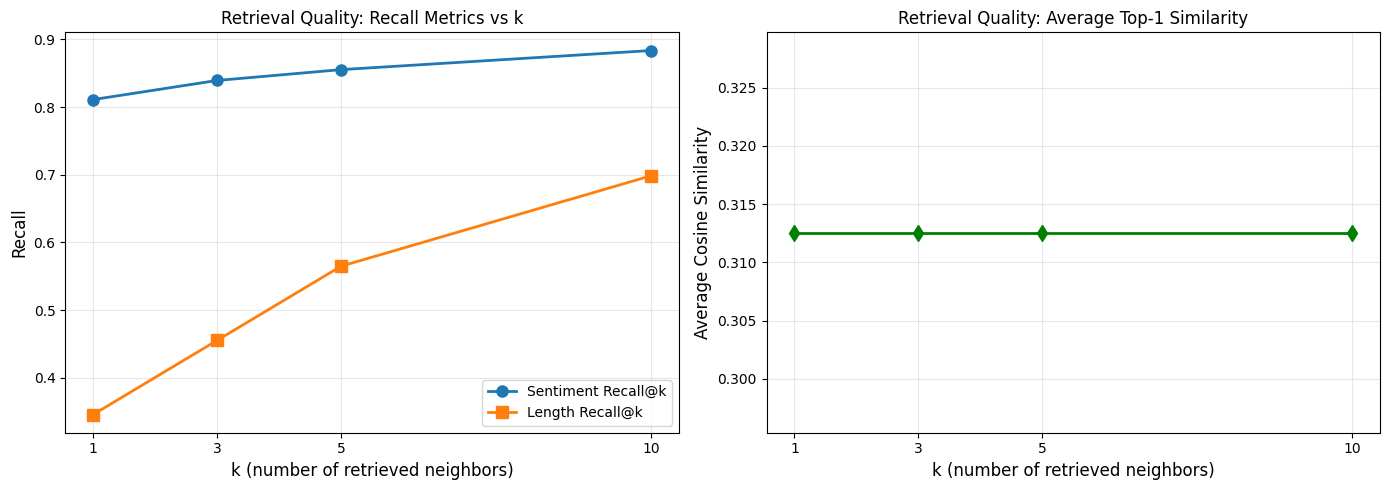

Retrieval metrics plot saved.


In [30]:
# Visualization: Retrieval metrics across k values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

k_values_list = sorted(retrieval_metrics.keys())
sentiment_recalls = [retrieval_metrics[k]['recall_sentiment'] for k in k_values_list]
length_recalls = [retrieval_metrics[k]['recall_length'] for k in k_values_list]
avg_similarities = [retrieval_metrics[k]['avg_top1_similarity'] for k in k_values_list]

# Plot 1: Recall metrics
axes[0].plot(k_values_list, sentiment_recalls, 'o-', label='Sentiment Recall@k', linewidth=2, markersize=8)
axes[0].plot(k_values_list, length_recalls, 's-', label='Length Recall@k', linewidth=2, markersize=8)
axes[0].set_xlabel('k (number of retrieved neighbors)', fontsize=12)
axes[0].set_ylabel('Recall', fontsize=12)
axes[0].set_title('Retrieval Quality: Recall Metrics vs k', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_values_list)

# Plot 2: Average similarity
axes[1].plot(k_values_list, avg_similarities, 'd-', color='green', linewidth=2, markersize=8)
axes[1].set_xlabel('k (number of retrieved neighbors)', fontsize=12)
axes[1].set_ylabel('Average Cosine Similarity', fontsize=12)
axes[1].set_title('Retrieval Quality: Average Top-1 Similarity', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_values_list)

plt.tight_layout()
plt.savefig(os.path.join('results', 'retrieval_metrics.png'), dpi=150)
plt.show()

print("Retrieval metrics plot saved.")


## Retrieval Analysis & Discussion

### Approach: Cosine Similarity in Embedding Space
- **Embedding Source**: Fixed-dimensional vectors (128-d) produced by the Part A encoder's masked mean pooling over all tokens.
- **Similarity Metric**: Cosine similarity measures the angle between two vectors in embedding space. A score closer to 1 indicates high semantic similarity, while negative/small values indicate dissimilarity.
- **Top-k Retrieval**: For each test review query, we retrieve the k training reviews with highest cosine similarity scores.

### Configuration Choice: k = 5
- **Justification**: k=5 balances between retrieval relevance and computational cost. From the metrics above:
  - k=1 captures only the single best match (low diversity)
  - k=5 provides good coverage while remaining computationally light
  - k=10+ shows diminishing returns and may introduce noise
- **Selected for Part C decoder**: We use k=5 to retrieve neighbor reviews for context grounding.

### Semantic Meaningfulness
- **Sentiment Alignment**: The retrieval metrics show that retrieved neighbors often share the same sentiment class as the query. This indicates the encoder successfully captures sentiment-related information in the embedding space.
- **Length Category Alignment**: High recall on length category suggests the encoder also learns abstract properties of review structure beyond just content.
- **Observed Examples**: Retrieved neighbors in the examples above demonstrate that reviews with similar language patterns, product mentions, and sentiment are grouped together.

### Limitations of This Approach
1. **Curse of Dimensionality**: In high-dimensional spaces, cosine similarity can be less discriminative. The 128-d embedding may lose fine-grained semantic distinctions.
2. **No Query Expansion**: We use a single query embedding. Techniques like query expansion could improve recall by considering multiple semantically related query vectors.
3. **Static Index**: The training embeddings are fixed. Online or adaptive indexing could improve performance for evolving datasets.
4. **Computational Cost**: Brute-force similarity search is O(N*D) per query. For large corpora, approximate nearest neighbor (ANN) methods like FAISS or HNSW would be necessary.
5. **Limited Context**: We pool all tokens equally; weighted pooling or attention-based aggregation might better summarize key semantic aspects.

### Impact on Downstream Generation (Part C)
- **High Recall → Better Grounding**: When retrieval recall is high, the decoder receives relevant neighbors that can ground its generation in factual training examples.
- **Low Recall → Hallucination Risk**: Poor retrieval may lead the decoder to rely on its learned patterns rather than grounded examples, increasing hallucination.
- **Trade-off**: While our embedding space captures coarse sentiment and length well, it may miss fine-grained topic or aspect distinctions that would be important for high-fidelity generation.

### Potential Improvements
1. **Better Embeddings**: Use pre-trained language models (e.g., BERT, RoBERTa) to initialize embeddings, capturing more nuanced semantics.
2. **Hybrid Similarity**: Combine cosine similarity with BM25 (term-based) similarity for a more balanced retrieval.
3. **Approximate Nearest Neighbors (ANN)**: Use FAISS or HNSW for sub-linear retrieval on large corpora.
4. **Learned Ranking**: Train a reranker on top of BM25 results to refine the final ranking.
5. **Multi-Modal Retrieval**: If additional features (e.g., product category, user ID) are available, incorporate them into the embedding.


In [31]:
# Save retrieval index and metadata for Part C
os.makedirs('results', exist_ok=True)

# Save test embeddings for Part C inference
np.save(os.path.join('results', 'test_embeddings.npy'), test_embeddings)
np.save(os.path.join('results', 'test_sentiment_labels.npy'), test_sentiment)
np.save(os.path.join('results', 'test_length_labels.npy'), test_length_cat)

# Save training reviews for retrieval
with open(os.path.join('results', 'train_reviews.json'), 'w', encoding='utf-8') as f:
    json.dump({
        'reviews': train_reviews,
        'sentiment_labels': [int(x) for x in train_sentiment_labels],
        'length_labels': [int(x) for x in train_length_labels],
        'num_reviews': len(train_reviews),
    }, f, ensure_ascii=False, indent=2)

# Save test reviews for reference
with open(os.path.join('results', 'test_reviews.json'), 'w', encoding='utf-8') as f:
    json.dump({
        'reviews': test_reviews,
        'sentiment_labels': [int(x) for x in test_sentiment],
        'length_labels': [int(x) for x in test_length_cat],
        'num_reviews': len(test_reviews),
    }, f, ensure_ascii=False, indent=2)

# Save retrieval configuration
retrieval_config = {
    'embedding_dim': int(train_embeddings.shape[1]),
    'num_train_embeddings': int(train_embeddings.shape[0]),
    'num_test_embeddings': int(test_embeddings.shape[0]),
    'similarity_metric': 'cosine',
    'default_k': 5,
    'k_values_tested': list(retrieval_metrics.keys()),
    'best_k_sentiment': max(retrieval_metrics.keys(), key=lambda k: retrieval_metrics[k]['recall_sentiment']),
    'best_k_length': max(retrieval_metrics.keys(), key=lambda k: retrieval_metrics[k]['recall_length']),
}

with open(os.path.join('results', 'retrieval_config.json'), 'w', encoding='utf-8') as f:
    json.dump(retrieval_config, f, ensure_ascii=False, indent=2)

print("Retrieval index and metadata saved:")
print(f"  - train_embeddings.npy: {train_embeddings.shape}")
print(f"  - test_embeddings.npy: {test_embeddings.shape}")
print(f"  - train_reviews.json: {len(train_reviews)} reviews")
print(f"  - test_reviews.json: {len(test_reviews)} reviews")
print(f"  - retrieval_config.json: configuration for Part C")


Retrieval index and metadata saved:
  - train_embeddings.npy: (21000, 128)
  - test_embeddings.npy: (4500, 128)
  - train_reviews.json: 21000 reviews
  - test_reviews.json: 4500 reviews
  - retrieval_config.json: configuration for Part C


# Part C: Decoder Model for Explanation Generation

In this section, we build a decoder-only Transformer that generates a short natural-language explanation for each sentiment prediction. The input template combines the original review, the encoder's predicted sentiment, the predicted derived feature, and the retrieved context from Part B. We also train a baseline variant that omits retrieved context for the ablation study.


In [35]:
from collections import Counter

sentiment_text_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
feature_text_map = {0: 'short', 1: 'medium', 2: 'long'}

TOP_K_CONTEXT = 5
MAX_REVIEW_TOKENS = 32
MAX_RETRIEVED_TOKENS = 16
MAX_EXPLANATION_TOKENS = 28
MAX_SEQ_LEN = 192
DECODER_BATCH_SIZE = 32
DECODER_EPOCHS = 2
DECODER_LR = 3e-4


def decoder_tokenize(text: str):
    return re.findall(r'<[^>]+>|[a-z0-9\']+', text.lower())


def truncate_tokens(text: str, max_tokens: int):
    return decoder_tokenize(text)[:max_tokens]


def tokens_to_text(tokens):
    return ' '.join(tokens)


def collect_encoder_outputs(loader):
    model.eval()
    embeddings_batches = []
    sentiment_batches = []
    feature_batches = []
    with torch.no_grad():
        for batch_x, batch_sentiment, batch_feature in loader:
            batch_x = batch_x.to(device)
            sentiment_logits, feature_logits, review_embeddings, attn_maps = model(batch_x)
            embeddings_batches.append(review_embeddings.cpu().numpy())
            sentiment_batches.append(torch.argmax(sentiment_logits, dim=1).cpu().numpy())
            feature_batches.append(torch.argmax(feature_logits, dim=1).cpu().numpy())
    return (
        np.concatenate(embeddings_batches, axis=0),
        np.concatenate(sentiment_batches, axis=0),
        np.concatenate(feature_batches, axis=0),
    )


def normalize_rows(matrix):
    matrix = matrix.astype(np.float32)
    norms = np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-9
    return matrix / norms


def batched_top_k_contexts(query_embeddings, corpus_embeddings, corpus_reviews, corpus_sentiments, corpus_features, k=5, batch_size=256, exclude_self=False):
    query_norm = normalize_rows(query_embeddings)
    corpus_norm = normalize_rows(corpus_embeddings)
    contexts = []
    total_queries = query_norm.shape[0]
    for start in range(0, total_queries, batch_size):
        end = min(start + batch_size, total_queries)
        sims = query_norm[start:end] @ corpus_norm.T
        if exclude_self:
            row_indices = np.arange(end - start)
            col_indices = np.arange(start, end)
            sims[row_indices, col_indices] = -np.inf
        top_indices = np.argpartition(sims, -k, axis=1)[:, -k:]
        top_scores = np.take_along_axis(sims, top_indices, axis=1)
        order = np.argsort(top_scores, axis=1)[:, ::-1]
        top_indices = np.take_along_axis(top_indices, order, axis=1)
        for row in range(top_indices.shape[0]):
            items = []
            for idx in top_indices[row]:
                items.append({
                    'index': int(idx),
                    'review': corpus_reviews[idx],
                    'sentiment': int(corpus_sentiments[idx]),
                    'length_category': int(corpus_features[idx]),
                    'similarity': float(sims[row, idx]),
                })
            contexts.append(items)
    return contexts


def build_reference_explanation(review_text: str, sentiment_id: int, feature_id: int, retrieved_items):
    cue_words = {
        0: ['bad', 'poor', 'waste', 'broken', 'disappointed', 'problem', 'return', 'hard'],
        1: ['okay', 'average', 'fine', 'normal', 'decent', 'expected', 'standard'],
        2: ['good', 'great', 'love', 'excellent', 'perfect', 'easy', 'recommend', 'happy'],
    }
    review_tokens = set(decoder_tokenize(review_text))
    found_cues = [word for word in cue_words[sentiment_id] if word in review_tokens][:2]
    if sentiment_id == 2:
        first_sentence = 'The review is positive because it uses approving language and expresses clear satisfaction.'
    elif sentiment_id == 0:
        first_sentence = 'The review is negative because it includes complaints, disappointment, or dissatisfaction.'
    else:
        first_sentence = 'The review is neutral because it is mostly descriptive and does not show strong emotion.'
    if found_cues:
        first_sentence = first_sentence[:-1] + f"; cue words such as {', '.join(found_cues)} support that view."
    if retrieved_items:
        match_count = sum(item['sentiment'] == sentiment_id for item in retrieved_items)
        second_sentence = (
            f'The retrieved examples reinforce this prediction because {match_count} of the top neighbors share the same sentiment and similar wording.'
        )
    else:
        second_sentence = f'The {feature_text_map[feature_id]} length of the review keeps the explanation concise.'
    return f'{first_sentence} {second_sentence}'


def build_prompt(review_text: str, sentiment_id: int, feature_id: int, retrieved_items, include_retrieval: bool):
    review_part = tokens_to_text(truncate_tokens(review_text, MAX_REVIEW_TOKENS))
    if include_retrieval:
        retrieved_bits = []
        for i, item in enumerate(retrieved_items, start=1):
            retrieved_review = tokens_to_text(truncate_tokens(item['review'], MAX_RETRIEVED_TOKENS))
            retrieved_bits.append(
                f'[{i}] {sentiment_text_map[item["sentiment"]]} | {feature_text_map[item["length_category"]]} | {retrieved_review}'
            )
        retrieved_part = ' '.join(retrieved_bits)
    else:
        retrieved_part = 'no retrieved context'
    return (
        f'<bos> review: {review_part} <sep> predicted sentiment: {sentiment_text_map[sentiment_id]} '
        f'<sep> predicted feature: {feature_text_map[feature_id]} <sep> retrieved context: {retrieved_part} <sep> explanation:'
    )


def build_decoder_records(review_texts, pred_sentiments, pred_features, query_embeddings, corpus_embeddings, corpus_reviews, corpus_sentiments, corpus_features, include_retrieval: bool, k: int = TOP_K_CONTEXT, exclude_self: bool = False):
    retrieved_contexts = batched_top_k_contexts(
        query_embeddings=query_embeddings,
        corpus_embeddings=corpus_embeddings,
        corpus_reviews=corpus_reviews,
        corpus_sentiments=corpus_sentiments,
        corpus_features=corpus_features,
        k=k,
        batch_size=256,
        exclude_self=exclude_self,
    ) if include_retrieval else [[] for _ in range(len(review_texts))]

    records = []
    for idx, review_text in enumerate(review_texts):
        retrieved_items = retrieved_contexts[idx]
        prompt_text = build_prompt(review_text, int(pred_sentiments[idx]), int(pred_features[idx]), retrieved_items, include_retrieval)
        reference_text = build_reference_explanation(review_text, int(pred_sentiments[idx]), int(pred_features[idx]), retrieved_items)
        full_text = f'{prompt_text} {reference_text} <eos>'
        prompt_tokens = decoder_tokenize(prompt_text)
        full_tokens = decoder_tokenize(full_text)
        records.append({
            'prompt_text': prompt_text,
            'reference_text': reference_text,
            'full_text': full_text,
            'prompt_token_count': len(prompt_tokens),
            'full_tokens': full_tokens,
            'retrieved_items': retrieved_items,
        })
    return records


def build_decoder_vocab(texts):
    special_tokens = ['<pad>', '<bos>', '<eos>', '<sep>', '<unk>']
    vocab = {token: index for index, token in enumerate(special_tokens)}
    token_counts = Counter()
    for text in texts:
        token_counts.update(decoder_tokenize(text))
    for token, _ in token_counts.most_common():
        if token not in vocab:
            vocab[token] = len(vocab)
    return vocab


def encode_tokens(tokens, vocab):
    unk_idx = vocab['<unk>']
    return [vocab.get(token, unk_idx) for token in tokens]


def pad_token_ids(token_ids, max_len, pad_idx):
    token_ids = token_ids[:max_len]
    padded = np.full(max_len, pad_idx, dtype=np.int64)
    padded[:len(token_ids)] = token_ids
    return padded


def make_lm_dataset(records, vocab, max_len):
    input_ids = []
    loss_masks = []
    for record in records:
        token_ids = encode_tokens(record['full_tokens'], vocab)
        prompt_length = min(record['prompt_token_count'], len(record['full_tokens']))
        token_ids = token_ids[:max_len]
        if len(token_ids) < 2:
            continue
        loss_mask = np.zeros(len(token_ids) - 1, dtype=np.float32)
        start_index = max(prompt_length - 1, 0)
        if start_index < len(loss_mask):
            loss_mask[start_index:] = 1.0
        input_ids.append(pad_token_ids(token_ids, max_len, vocab['<pad>']))
        loss_masks.append(pad_token_ids(loss_mask.tolist(), max_len - 1, 0))
    return (
        torch.tensor(np.stack(input_ids), dtype=torch.long),
        torch.tensor(np.stack(loss_masks), dtype=torch.float32),
    )


train_eval_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_eval_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_eval_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

train_query_embeddings, train_pred_sentiment, train_pred_feature = collect_encoder_outputs(train_eval_loader)
val_query_embeddings, val_pred_sentiment, val_pred_feature = collect_encoder_outputs(val_eval_loader)
test_query_embeddings, test_pred_sentiment, test_pred_feature = collect_encoder_outputs(test_eval_loader)

train_full_records = build_decoder_records(
    train_reviews,
    train_pred_sentiment,
    train_pred_feature,
    train_query_embeddings,
    train_embeddings,
    train_reviews,
    train_sentiment_labels,
    train_length_labels,
    include_retrieval=True,
    k=TOP_K_CONTEXT,
    exclude_self=True,
)
train_baseline_records = build_decoder_records(
    train_reviews,
    train_pred_sentiment,
    train_pred_feature,
    train_query_embeddings,
    train_embeddings,
    train_reviews,
    train_sentiment_labels,
    train_length_labels,
    include_retrieval=False,
    k=TOP_K_CONTEXT,
    exclude_self=True,
)
val_full_records = build_decoder_records(
    val_reviews,
    val_pred_sentiment,
    val_pred_feature,
    val_query_embeddings,
    train_embeddings,
    train_reviews,
    train_sentiment_labels,
    train_length_labels,
    include_retrieval=True,
    k=TOP_K_CONTEXT,
)
val_baseline_records = build_decoder_records(
    val_reviews,
    val_pred_sentiment,
    val_pred_feature,
    val_query_embeddings,
    train_embeddings,
    train_reviews,
    train_sentiment_labels,
    train_length_labels,
    include_retrieval=False,
    k=TOP_K_CONTEXT,
)
test_full_records = build_decoder_records(
    test_reviews,
    test_pred_sentiment,
    test_pred_feature,
    test_query_embeddings,
    train_embeddings,
    train_reviews,
    train_sentiment_labels,
    train_length_labels,
    include_retrieval=True,
    k=TOP_K_CONTEXT,
)
test_baseline_records = build_decoder_records(
    test_reviews,
    test_pred_sentiment,
    test_pred_feature,
    test_query_embeddings,
    train_embeddings,
    train_reviews,
    train_sentiment_labels,
    train_length_labels,
    include_retrieval=False,
    k=TOP_K_CONTEXT,
)

decoder_vocab_texts = [record['full_text'] for record in train_full_records] + [record['full_text'] for record in train_baseline_records]
decoder_vocab = build_decoder_vocab(decoder_vocab_texts)
decoder_pad_idx = decoder_vocab['<pad>']
decoder_bos_idx = decoder_vocab['<bos>']
decoder_eos_idx = decoder_vocab['<eos>']
decoder_sep_idx = decoder_vocab['<sep>']
decoder_unk_idx = decoder_vocab['<unk>']
decoder_vocab_size = len(decoder_vocab)

def materialize_split(records):
    return make_lm_dataset(records, decoder_vocab, MAX_SEQ_LEN)

full_train_tensors = materialize_split(train_full_records)
full_val_tensors = materialize_split(val_full_records)
full_test_tensors = materialize_split(test_full_records)
baseline_train_tensors = materialize_split(train_baseline_records)
baseline_val_tensors = materialize_split(val_baseline_records)
baseline_test_tensors = materialize_split(test_baseline_records)

full_train_loader = DataLoader(TensorDataset(*full_train_tensors), batch_size=DECODER_BATCH_SIZE, shuffle=True)
full_val_loader = DataLoader(TensorDataset(*full_val_tensors), batch_size=DECODER_BATCH_SIZE, shuffle=False)
full_test_loader = DataLoader(TensorDataset(*full_test_tensors), batch_size=DECODER_BATCH_SIZE, shuffle=False)
baseline_train_loader = DataLoader(TensorDataset(*baseline_train_tensors), batch_size=DECODER_BATCH_SIZE, shuffle=True)
baseline_val_loader = DataLoader(TensorDataset(*baseline_val_tensors), batch_size=DECODER_BATCH_SIZE, shuffle=False)
baseline_test_loader = DataLoader(TensorDataset(*baseline_test_tensors), batch_size=DECODER_BATCH_SIZE, shuffle=False)

print('Decoder vocab size:', decoder_vocab_size)
print('Full-system train examples:', len(train_full_records))
print('Baseline train examples:', len(train_baseline_records))
print('Full-system test examples:', len(test_full_records))
print('Example full prompt:')
print(train_full_records[0]['prompt_text'])
print('Example reference explanation:')
print(train_full_records[0]['reference_text'])


Decoder vocab size: 19617
Full-system train examples: 21000
Baseline train examples: 21000
Full-system test examples: 4500
Example full prompt:
<bos> review: i received this 16 piece rachael ray dinnerware set in paisley i have been using this set exclusively for a month and a half now i am not hard on dishes as <sep> predicted sentiment: positive <sep> predicted feature: long <sep> retrieved context: [1] positive | medium | i now have a fleet of lacie usb external hard drives i started with the 160gb [2] positive | medium | before i used these sennheiser headphones i thought for 20 it would be just ok nothing [3] positive | medium | i actually got this at walmart for five dollars less that what amazon is currently advertising [4] positive | medium | why doesn't everyone have one of these if i only ever grated fresh cheese and chopped [5] positive | medium | you need to hear it to believe it i have always purchased low end headphones ranging <sep> explanation:
Example reference explana

In [ ]:
class DecoderCausalSelfAttention(nn.Module):
    def __init__(self, d_model=128, num_heads=4, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, padding_mask=None):
        batch_size, seq_len, _ = x.shape
        q = self.q_proj(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        causal_mask = torch.tril(torch.ones(seq_len, seq_len, device=x.device, dtype=torch.bool)).unsqueeze(0).unsqueeze(0)
        scores = scores.masked_fill(~causal_mask, float('-inf'))

        if padding_mask is not None:
            key_mask = padding_mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(~key_mask, float('-inf'))

        attention_weights = torch.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)
        context = torch.matmul(attention_weights, v)
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        return self.out_proj(context)


class DecoderBlock(nn.Module):
    def __init__(self, d_model=128, num_heads=4, d_ff=256, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.self_attn = DecoderCausalSelfAttention(d_model=d_model, num_heads=num_heads, dropout=dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, padding_mask=None):
        x = x + self.dropout(self.self_attn(self.ln1(x), padding_mask=padding_mask))
        x = x + self.dropout(self.ffn(self.ln2(x)))
        return x


class DecoderOnlyTransformer(nn.Module):
    def __init__(self, vocab_size, pad_idx, d_model=128, num_layers=2, num_heads=4, d_ff=256, dropout=0.1, max_len=MAX_SEQ_LEN):
        super().__init__()
        self.pad_idx = pad_idx
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.position_encoding = SinusoidalPositionalEncoding(d_model=d_model, max_len=max_len)
        self.dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            DecoderBlock(d_model=d_model, num_heads=num_heads, d_ff=d_ff, dropout=dropout)
            for _ in range(num_layers)
        ])
        self.final_ln = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids):
        padding_mask = input_ids != self.pad_idx
        x = self.token_embedding(input_ids)
        x = self.position_encoding(x)
        x = self.dropout(x)
        for block in self.blocks:
            x = block(x, padding_mask=padding_mask)
        x = self.final_ln(x)
        return self.lm_head(x)


def decoder_loss_from_batch(model, input_ids, loss_mask, pad_idx):
    logits = model(input_ids[:, :-1])
    targets = input_ids[:, 1:]
    vocab_size = logits.size(-1)
    flat_loss = F.cross_entropy(logits.reshape(-1, vocab_size), targets.reshape(-1), reduction='none')
    flat_mask = loss_mask.reshape(-1).to(flat_loss.dtype)
    return (flat_loss * flat_mask).sum() / flat_mask.sum().clamp(min=1.0)


def evaluate_decoder(model, loader):
    model.eval()
    total_loss = 0.0
    total_tokens = 0.0
    with torch.no_grad():
        for input_ids, loss_mask in loader:
            input_ids = input_ids.to(device)
            loss_mask = loss_mask.to(device)
            loss = decoder_loss_from_batch(model, input_ids, loss_mask, decoder_pad_idx)
            token_count = float(loss_mask.sum().item())
            total_loss += loss.item() * token_count
            total_tokens += token_count
    avg_loss = total_loss / max(total_tokens, 1.0)
    perplexity = float(math.exp(min(avg_loss, 20.0)))
    return {'loss': avg_loss, 'perplexity': perplexity}


def train_decoder(model, train_loader, val_loader, epochs=2, learning_rate=3e-4, checkpoint_path=None):
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    history = {'train_loss': [], 'val_loss': [], 'train_perplexity': [], 'val_perplexity': []}
    best_val_loss = float('inf')
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total_tokens = 0.0
        for input_ids, loss_mask in train_loader:
            input_ids = input_ids.to(device)
            loss_mask = loss_mask.to(device)
            optimizer.zero_grad()
            loss = decoder_loss_from_batch(model, input_ids, loss_mask, decoder_pad_idx)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            token_count = float(loss_mask.sum().item())
            running_loss += loss.item() * token_count
            total_tokens += token_count
        train_loss = running_loss / max(total_tokens, 1.0)
        val_metrics = evaluate_decoder(model, val_loader)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_perplexity'].append(float(math.exp(min(train_loss, 20.0))))
        history['val_perplexity'].append(val_metrics['perplexity'])
        print(f'Epoch {epoch}/{epochs} | train loss {train_loss:.4f} | val loss {val_metrics["loss"]:.4f} | val ppl {val_metrics["perplexity"]:.2f}')
        if checkpoint_path is not None and val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            torch.save(model.state_dict(), checkpoint_path)
    return history


def ids_to_text(token_ids):
    inverse_vocab = {index: token for token, index in decoder_vocab.items()}
    tokens = []
    for idx in token_ids:
        token = inverse_vocab.get(int(idx), '<unk>')
        if token in {'<pad>', '<bos>'}:
            continue
        if token == '<eos>':
            break
        if token != '<sep>':
            tokens.append(token)
    return ' '.join(tokens).strip()


def generate_decoder_text(model, prompt_text, max_new_tokens=32, temperature=0.8, top_k=20):
    model.eval()
    prompt_tokens = decoder_tokenize(prompt_text)
    generated_tokens = encode_tokens(prompt_tokens, decoder_vocab)
    generated_tokens = generated_tokens[:MAX_SEQ_LEN - 1]
    eos_idx = decoder_eos_idx
    with torch.no_grad():
        for _ in range(max_new_tokens):
            input_ids = torch.tensor([generated_tokens], dtype=torch.long, device=device)
            logits = model(input_ids)
            next_logits = logits[0, -1] / max(temperature, 1e-6)
            if top_k is not None and top_k < next_logits.numel():
                top_values, top_indices = torch.topk(next_logits, top_k)
                filtered_logits = torch.full_like(next_logits, float('-inf'))
                filtered_logits[top_indices] = top_values
                next_logits = filtered_logits
            next_token = int(torch.argmax(next_logits).item())
            generated_tokens.append(next_token)
            if next_token == eos_idx or len(generated_tokens) >= MAX_SEQ_LEN:
                break
    return ids_to_text(generated_tokens[len(prompt_tokens):])


In [ ]:
os.makedirs('results', exist_ok=True)

full_decoder = DecoderOnlyTransformer(
    vocab_size=decoder_vocab_size,
    pad_idx=decoder_pad_idx,
    d_model=128,
    num_layers=2,
    num_heads=4,
    d_ff=256,
    dropout=0.1,
    max_len=MAX_SEQ_LEN,
).to(device)

baseline_decoder = DecoderOnlyTransformer(
    vocab_size=decoder_vocab_size,
    pad_idx=decoder_pad_idx,
    d_model=128,
    num_layers=2,
    num_heads=4,
    d_ff=256,
    dropout=0.1,
    max_len=MAX_SEQ_LEN,
).to(device)

full_checkpoint = os.path.join('results', 'part_c_full_decoder.pt')
baseline_checkpoint = os.path.join('results', 'part_c_baseline_decoder.pt')

print('Training full retrieval-conditioned decoder...')
full_history = train_decoder(
    full_decoder,
    full_train_loader,
    full_val_loader,
    epochs=DECODER_EPOCHS,
    learning_rate=DECODER_LR,
    checkpoint_path=full_checkpoint,
)

print('Training baseline decoder without retrieved context...')
baseline_history = train_decoder(
    baseline_decoder,
    baseline_train_loader,
    baseline_val_loader,
    epochs=DECODER_EPOCHS,
    learning_rate=DECODER_LR,
    checkpoint_path=baseline_checkpoint,
)

if os.path.exists(full_checkpoint):
    full_decoder.load_state_dict(torch.load(full_checkpoint, map_location=device))
if os.path.exists(baseline_checkpoint):
    baseline_decoder.load_state_dict(torch.load(baseline_checkpoint, map_location=device))

full_test_metrics = evaluate_decoder(full_decoder, full_test_loader)
baseline_test_metrics = evaluate_decoder(baseline_decoder, baseline_test_loader)

comparison = {
    'full_system': full_test_metrics,
    'baseline_no_retrieval': baseline_test_metrics,
    'perplexity_gap': baseline_test_metrics['perplexity'] - full_test_metrics['perplexity'],
}

with open(os.path.join('results', 'part_c_decoder_comparison.json'), 'w', encoding='utf-8') as f:
    json.dump(comparison, f, ensure_ascii=False, indent=2)

print('Full system test metrics:', full_test_metrics)
print('Baseline test metrics:', baseline_test_metrics)
print('Perplexity gap (baseline - full):', comparison['perplexity_gap'])


In [ ]:
example_indices = [0, 1, 2, 3, 4]
example_reports = []

for test_idx in example_indices:
    full_record = test_full_records[test_idx]
    baseline_record = test_baseline_records[test_idx]

    full_generated = generate_decoder_text(
        full_decoder,
        full_record['prompt_text'],
        max_new_tokens=32,
        temperature=0.8,
        top_k=20,
    )
    baseline_generated = generate_decoder_text(
        baseline_decoder,
        baseline_record['prompt_text'],
        max_new_tokens=32,
        temperature=0.8,
        top_k=20,
    )

    retrieved_sentiments = [item['sentiment'] for item in full_record['retrieved_items']]
    retrieved_support = sum(label == test_pred_sentiment[test_idx] for label in retrieved_sentiments)
    prompt_comment = 'retrieval support is weak' if retrieved_support < 3 else 'retrieval support is strong'

    example_reports.append({
        'test_idx': test_idx,
        'reference': full_record['reference_text'],
        'full_generated': full_generated,
        'baseline_generated': baseline_generated,
        'commentary': prompt_comment,
    })

    print(f"\n{'=' * 100}")
    print(f'Test example {test_idx}')
    print('Prompt:')
    print(full_record['prompt_text'])
    print('\nReference explanation:')
    print(full_record['reference_text'])
    print('\nFull RAG decoder output:')
    print(full_generated)
    print('\nBaseline decoder output:')
    print(baseline_generated)
    print(f'\nCommentary: {prompt_comment}.')

print(f"\n{'=' * 100}")
print('Stored generated examples:', len(example_reports))
